# Assignment: Istanbul Weather Forecasting

# Imports

In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.2 MB/s eta 0:00:00


In [3]:
import random, datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from keras_tuner import HyperModel, HyperParameters
from keras_tuner.tuners import RandomSearch

random.seed(46)
np.random.seed(46)
tf.random.set_seed(46)


# Functions

In [4]:
def load_and_preprocess(data_path):
    data = pd.read_csv(data_path)
    data['temp_celsius'] = data['temp'] - 273.15
    # data['date'] = pd.to_datetime(data['dt_iso']).dt.date
    data['date'] = pd.to_datetime(data['dt_iso'], format='%Y-%m-%d %H:%M:%S +0000 UTC').dt.date
    data = data.drop(columns=['dt_iso', 'temp'])
    data['date'] = pd.to_datetime(data['date'])
    data.set_index('date', inplace=True)
    return data.resample('D').mean()

def split_data_by_time(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    train_size = int(n * train_frac)
    val_size = int(n * val_frac)
    test_size = n - train_size - val_size
    train_df = df[:train_size]
    val_df = df[train_size:train_size+val_size]
    test_df = df[train_size+val_size:]
    return train_df, val_df, test_df


def scale_data(train_df, val_df, test_df, feature_columns, target_column):
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_x.fit(train_df[feature_columns])
    scaler_y.fit(train_df[[target_column]])
    train_x = scaler_x.transform(train_df[feature_columns])
    val_x = scaler_x.transform(val_df[feature_columns])
    test_x = scaler_x.transform(test_df[feature_columns])
    train_y = scaler_y.transform(train_df[[target_column]])
    val_y = scaler_y.transform(val_df[[target_column]])
    test_y = scaler_y.transform(test_df[[target_column]])
    return train_x, val_x, test_x, train_y.flatten(), val_y.flatten(), test_y.flatten(), scaler_x, scaler_y

def create_timewindow(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys), time_steps

def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()


def evaluate_predictions(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y):

    y_train_pred_ = model.predict(X_train, verbose=0)
    y_val_pred = model.predict(X_val, verbose=0)
    y_test_pred = model.predict(X_test, verbose=0)

    true_y_train_pred = scaler_y.inverse_transform(y_train_pred_)
    true_y_val_pred = scaler_y.inverse_transform(y_val_pred)
    true_y_test_pred = scaler_y.inverse_transform(y_test_pred)

    true_y_train = scaler_y.inverse_transform(y_train.reshape(-1, 1))
    true_y_val = scaler_y.inverse_transform(y_val.reshape(-1, 1))
    true_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    train_mse = mean_squared_error(true_y_train, true_y_train_pred)
    val_mse = mean_squared_error(true_y_val, true_y_val_pred)
    test_mse = mean_squared_error(true_y_test, true_y_test_pred)
    print("Train MSE:", train_mse, "Validation MSE:", val_mse, "Test MSE:", test_mse)
    return true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse


def plot_predictions_with_metrics(train_df, val_df, test_df, true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse, time_steps):
    plt.figure(dpi=200)
    plt.figure(figsize=(30, 10))
    # Train
    train_time = train_df.index[time_steps:]
    plt.plot(train_time, true_y_train, label='True Values (Train)', color='blue')
    plt.plot(train_time, true_y_train_pred, '--', label='Predicted Values (Train)', color='red')

    # Validation
    val_time = val_df.index[time_steps:]
    plt.plot(val_time, true_y_val, label='True Values (Validation)', color='green')
    plt.plot(val_time, true_y_val_pred, '--', label='Predicted Values (Validation)', color='orange')

    # Test
    test_time = test_df.index[time_steps:]
    plt.plot(test_time, true_y_test, label='True Values (Test)', color='purple')
    plt.plot(test_time, true_y_test_pred, '--', label='Predicted Values (Test)', color='pink')

    # Metrics
    plt.text(train_time.min(), true_y_train.max()*1.03, f"Train MSE: {train_mse:.4f}", fontsize=12)
    plt.text(train_time.min(), true_y_train.max()*0.98, f"Validation MSE: {val_mse:.4f}", fontsize=12)
    plt.text(train_time.min(), true_y_train.max()*0.93, f"Test MSE: {test_mse:.4f}", fontsize=12)

    plt.title('Actual and Predicted Values for All Data Sets')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_individual_series(data, figsize=(12, 4)):
    for column in data.columns:
        plt.figure(figsize=figsize)
        plt.plot(data.index, data[column], label=column, color='b')
        plt.title(f'Time Series Visualisation - {column}')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
        plt.show()

# Data Set

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
data_path = "/content/drive/MyDrive/Colab Notebooks/Sequence_Models/datasets_and_files/five_years_ist_weather.csv"

# Data Preparation

# Task 1: Veri ön işleme basamaklarını gerçekleştiriniz.

- Veriyi okuma ve ön işleme

- Feature'ları ve target'i seçme

- Veri setini zamana göre train, validasyon ve test seti olarak ayırmak

- Scale etme

- Time window'ları oluşturma

# Task 1 Solution

In [8]:
# load and preprocess data
df = load_and_preprocess(data_path)
print(df.head())



             humidity  wind_speed  clouds_all     pressure   dew_point  \
date                                                                     
2019-01-01  64.916667    5.473750   44.166667  1020.750000  273.427083   
2019-01-02  77.192308    3.921923   82.884615  1012.000000  275.625769   
2019-01-03  80.500000    5.600417   82.500000  1009.416667  275.659167   
2019-01-04  76.375000    7.986667   75.833333  1018.291667  272.872083   
2019-01-05  83.958333    6.635000   72.083333  1014.250000  274.025417   

            temp_celsius  
date                      
2019-01-01      6.390833  
2019-01-02      6.205000  
2019-01-03      5.622917  
2019-01-04      3.455833  
2019-01-05      3.334167  


In [9]:
# features and target
feature_columns=[col for col in df.columns if col != 'temp_celsius']
target_column='temp_celsius'

# split data by time
train_df, val_df, test_df = split_data_by_time(df, train_frac=0.8, val_frac=0.1)
print("Train Sizes:", train_df.shape, "Validation Sizes:", val_df.shape, "Test Sizes:", test_df.shape)

# scaling
train_scaled_x, val_scaled_x, test_scaled_x, train_scaled_y, val_scaled_y, test_scaled_y, scaler_x, scaler_y = scale_data(train_df, val_df, test_df, feature_columns, target_column)

# time window
X_train, y_train, time_steps = create_timewindow(train_scaled_x, train_scaled_y, time_steps = 5)
X_val, y_val, time_steps = create_timewindow(val_scaled_x, val_scaled_y, time_steps = 5)
X_test, y_test, time_steps = create_timewindow(test_scaled_x, test_scaled_y, time_steps = 5)

input_shape = (X_train.shape[1], X_train.shape[2])

Train Sizes: (1460, 6) Validation Sizes: (182, 6) Test Sizes: (184, 6)


# Task 2: Veri setini analiz ediniz.

- Değişkenlerin betimsel istatistikleri

- İstanbul'un hava sıcaklığı ortalaması standart sapması nasıl?

- Değişkenleri ayrı ayrı görselleştiriniz.

- Not: Anomaly ve correlation incelemeye gerek yok.

# Task 2 Solution

In [11]:
df.describe()

,humidity,wind_speed,clouds_all,pressure,dew_point,temp_celsius
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,70.896901,4.582238,31.097616,1015.936498,283.720919,16.221721
std,9.580190,1.858030,26.046656,6.175962,6.209948,7.202862
min,36.541667,0.792917,0.000000,991.625000,267.150000,-1.631667
25%,64.218750,3.150833,6.666667,1011.708333,279.051354,10.346979
50%,71.041667,4.401458,24.895833,1015.458333,283.752981,15.866042
75%,77.875000,5.763333,53.750000,1019.489583,288.946458,22.889479
max,96.750000,13.983333,100.000000,1038.750000,296.479167,31.163750


In [15]:
print(df["temp_celsius"].mean())
print(df["temp_celsius"].std())

16.221721170594783
7.202862427682763


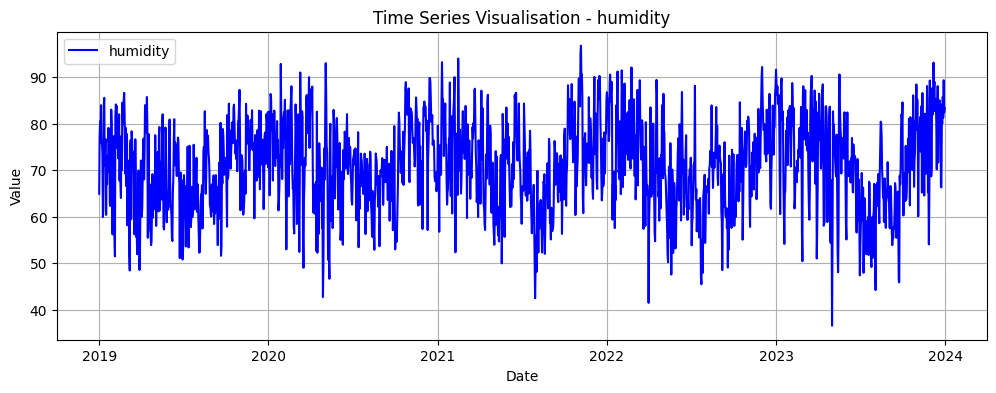

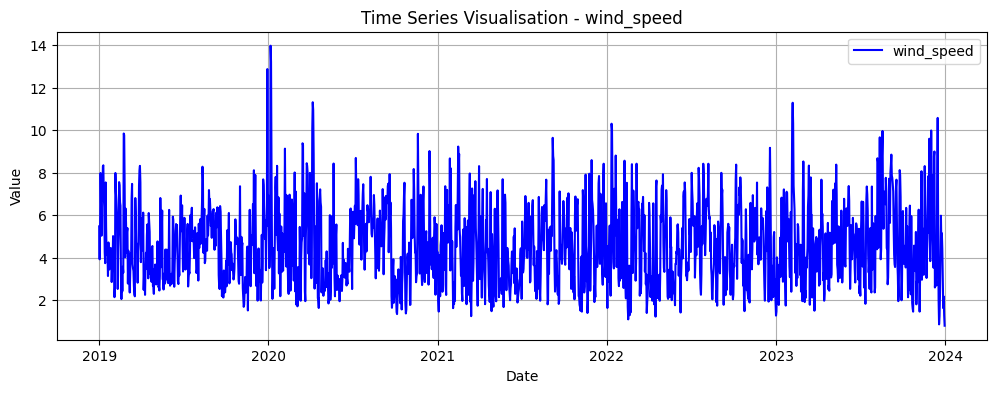

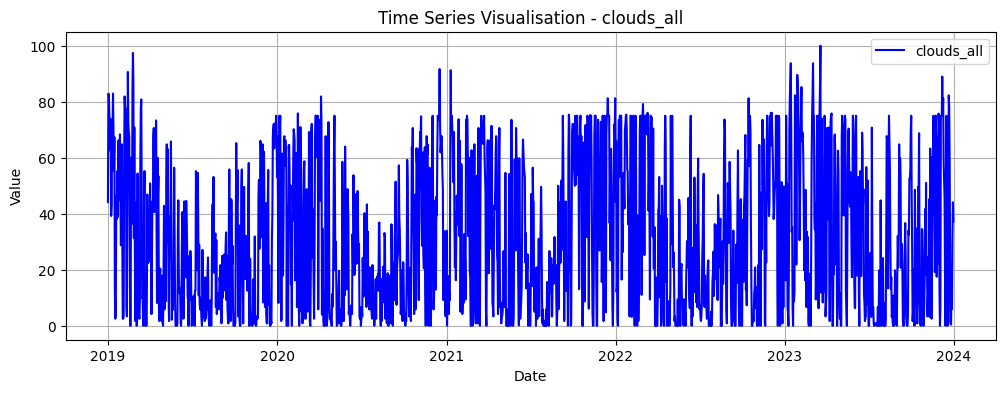

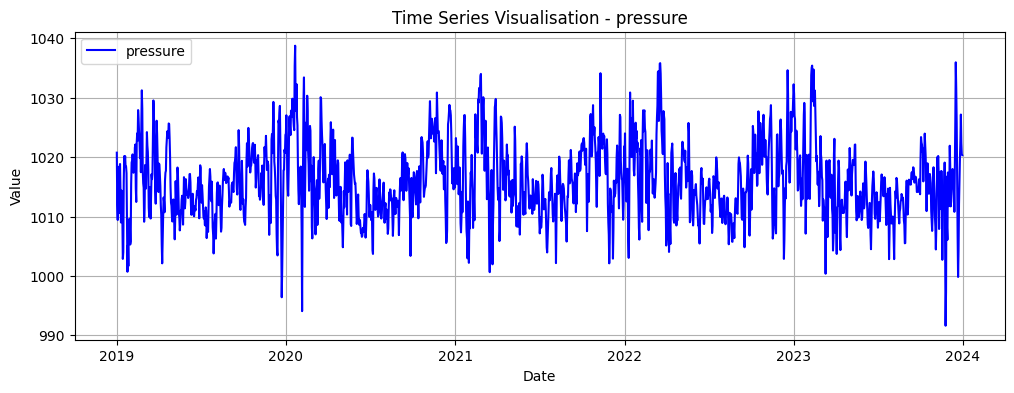

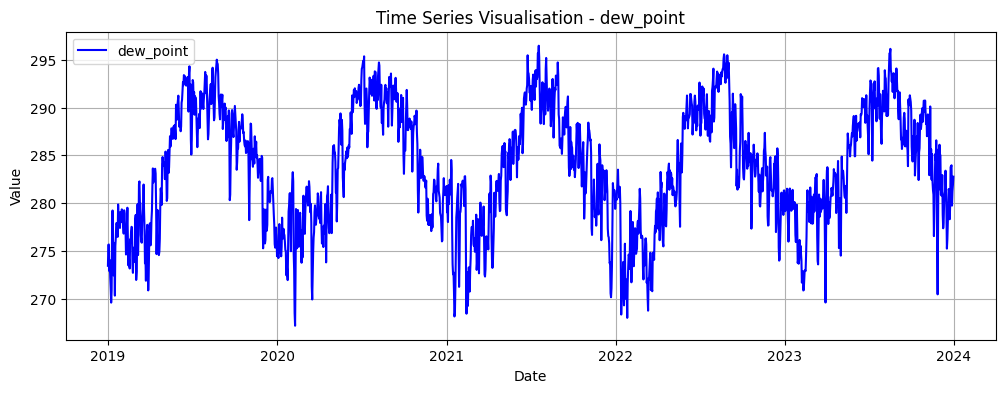

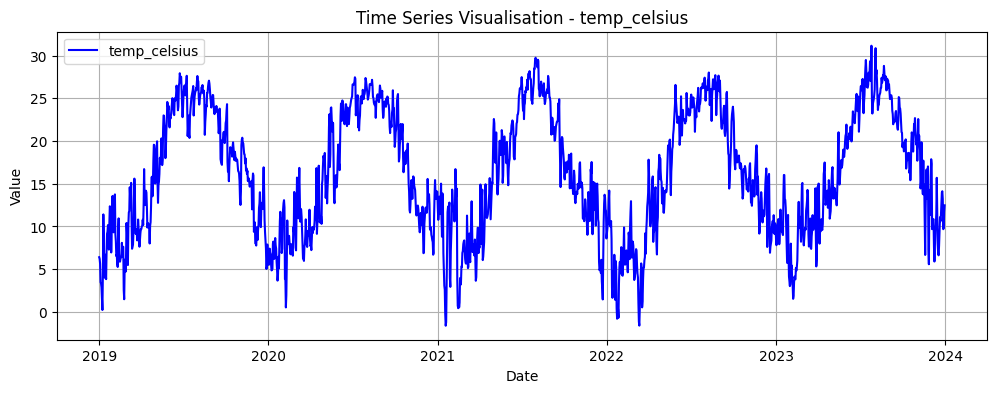

In [16]:
plot_individual_series(df)

# Model

# Task 3: Basit bir LSTM modeli kurunuz. İstediğiniz ayarlamaları yapabilirsiniz.


# Task 3 Solution

In [23]:
model = Sequential([
        LSTM(64, input_shape=input_shape,
             kernel_regularizer=l2(0.002)),
        Dense(1)
    ])

optimizer = Adam(learning_rate=0.001)


model.compile(optimizer=optimizer,
              loss='mean_squared_error',
              metrics=['mse'])

model.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=1e-5,
    verbose=1,
    restore_best_weights=True)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,985 (70.25 KB)

 Trainable params: 17,985 (70.25 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Modeli train ediniz. İstediğiniz ayarlamaları yapabilirsiniz.

# Task 4 Solution

In [24]:
start_time = datetime.datetime.now()

history = model.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    batch_size=64,
    verbose=1,
    callbacks=early_stopping
)

end_time = datetime.datetime.now()

total_duration = end_time - start_time
print("Training Time:", total_duration)

Epoch 1/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1085 - mse: 0.0898 - val_loss: 0.0548 - val_mse: 0.0375
Epoch 2/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0425 - mse: 0.0264 - val_loss: 0.0308 - val_mse: 0.0161
Epoch 3/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0251 - mse: 0.0114 - val_loss: 0.0225 - val_mse: 0.0100
Epoch 4/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0203 - mse: 0.0088 - val_loss: 0.0187 - val_mse: 0.0082
Epoch 5/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0174 - mse: 0.0076 - val_loss: 0.0161 - val_mse: 0.0071
Epoch 6/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0153 - mse: 0.0068 - val_loss: 0.0144 - val_mse: 0.0064
Epoch 7/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0139 - mse: 0.0063 - val_loss: 0.0130 - val_mse: 0.0059
Epoch 8/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0128 - mse: 0.0059 - val_loss: 0.0121 - val_mse: 0.0056
Epoch 9/500
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.01

# Performance Evaluation

# Task 5: Model performansını değerlendiriniz.

# Task 5 Solution

In [26]:
train_loss = model.evaluate(X_train, y_train, verbose=0)
val_loss = model.evaluate(X_val, y_val, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Train Loss: {train_loss[0]}", f"Validation Loss: {val_loss[0]}", f"Test Loss: {test_loss[0]}")

Train Loss: 0.003194407094269991 Validation Loss: 0.0031238296069204807 Test Loss: 0.004085946828126907


In [27]:
true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse = evaluate_predictions(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y)

Train MSE: 2.8406710562057307 Validation MSE: 2.7711309274920954 Test MSE: 3.7191111808280524


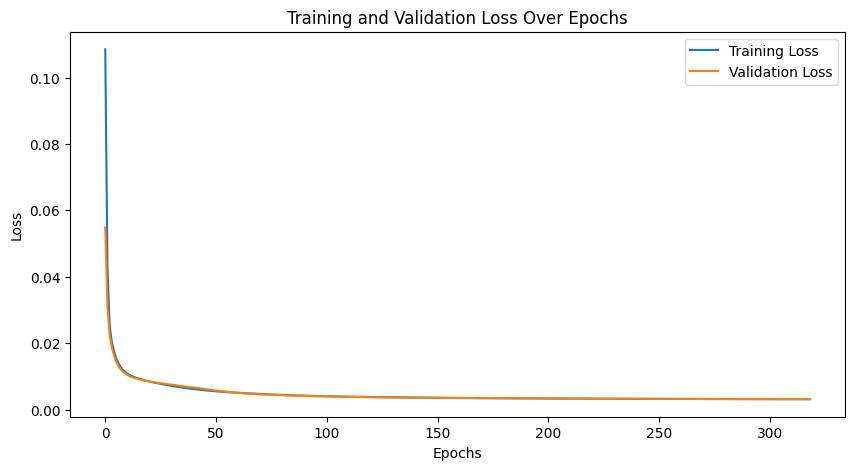

KeyError: 'accuracy'

<Figure size 1000x500 with 0 Axes>

In [39]:
plot_training_history(history)

<Figure size 1280x960 with 0 Axes>

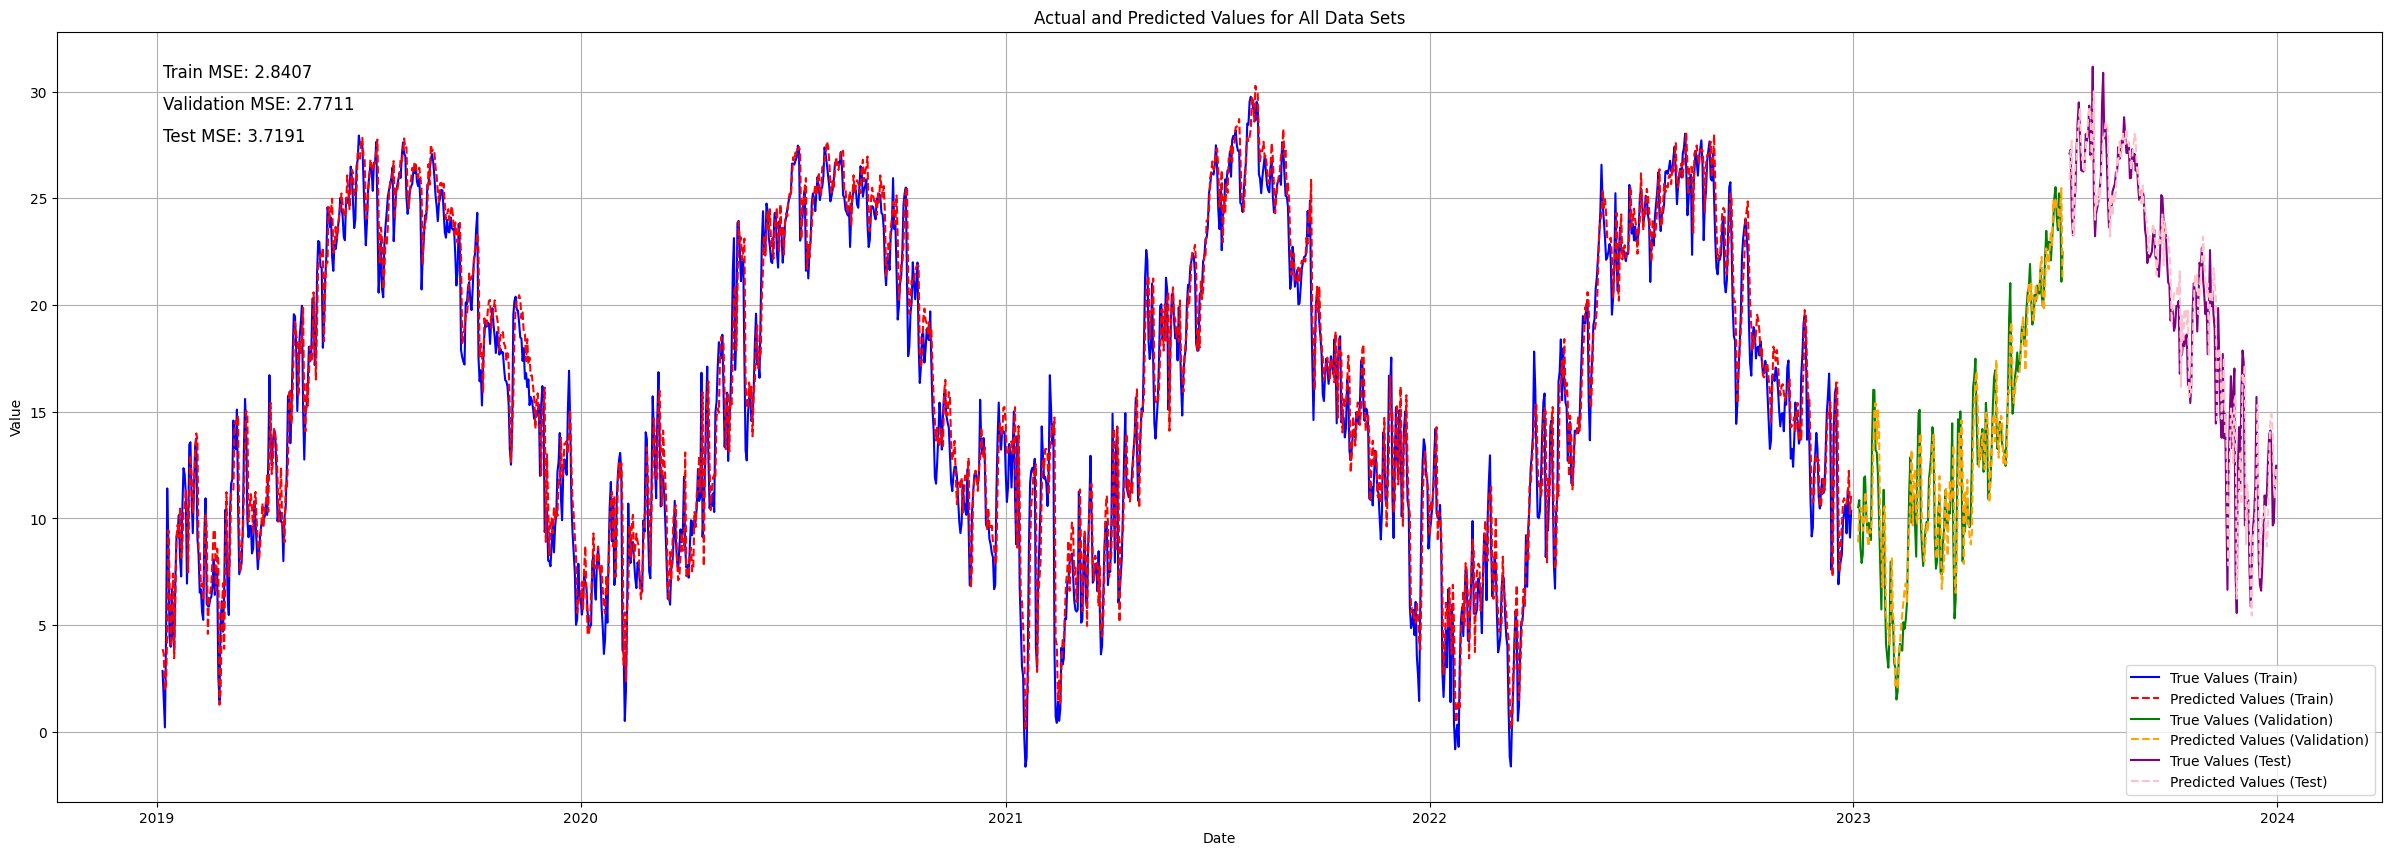

In [40]:
plot_predictions_with_metrics(train_df, val_df, test_df, true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse, time_steps)

# Hyperparameter Optimization

# Task 6: GRU için Hiperparametre arama uzayını hazırlayınız.

- Katman sayısı: 10

- Nöron sayısı: 16'dan 1024'e 32'şer adım. (return_squences bölümünü buna göre ayarlamayı unutmayın)

- Dropout:0.0 - 0.5 arası 0.1 adımlarla.

- Adam için learning rate başlangıc değeri 1e-5, 1e-2 aralığında.

- Dilediğiniz diğer ayarlamaları da yapabilirsiniz.

# Task 6 Solution

In [28]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=input_shape))

    num_layers = hp.Int('num_layers', 1, 10)
    for i in range(num_layers):
        model.add(GRU(
            units=hp.Int(f'units_{i}', min_value=16, max_value=1024, step=32),
            return_sequences=(i < num_layers - 1)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='LOG')),
        loss='mean_squared_error',
        metrics=['mse']
    )
    return model

# Task 7: Random Search Tuner ve Early Stopping yapılarını oluşturarak aramayı başladınız.

# Task 7 Solution

In [29]:
random_search_tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=40,
    executions_per_trial=1,
    directory='hyperparam_tuning',
    project_name='gru_tuning',
    overwrite=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True)

random_search_tuner.search(X_train, y_train,
                           epochs=500,
                           validation_data=(X_val, y_val),
                           callbacks=[early_stopping])

Trial 40 Complete [00h 01m 03s]
val_loss: 0.00955928023904562

Best val_loss So Far: 0.002727100858464837
Total elapsed time: 00h 29m 34s


# Task 8: Best modeli seçiniz ve performansını değerlendiriniz.

# Task 8 Solution

In [30]:
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]

In [31]:
def print_hyperparameters(hyperparameters):
    hp_df = pd.DataFrame(list(hyperparameters.items()), columns=['Hyperparameter', 'Value'])
    print(hp_df)

In [32]:
print_hyperparameters(best_hps.values)

   Hyperparameter       Value
0      num_layers    1.000000
1         units_0   48.000000
2       dropout_0    0.000000
3   learning_rate    0.000075
4         units_1  592.000000
5       dropout_1    0.200000
6         units_2   16.000000
7       dropout_2    0.000000
8         units_3  688.000000
9       dropout_3    0.300000
10        units_4  528.000000
11      dropout_4    0.300000
12        units_5  144.000000
13      dropout_5    0.100000
14        units_6  144.000000
15      dropout_6    0.200000
16        units_7  880.000000
17      dropout_7    0.400000
18        units_8  912.000000
19      dropout_8    0.400000
20        units_9  240.000000
21      dropout_9    0.400000


In [34]:
from joblib import dump, load

dump(best_hps, 'best_hps_gru.joblib')

['best_hps_gru.joblib']

In [36]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [37]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48)             │         7,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,161 (31.88 KB)

 Trainable params: 8,065 (31.50 KB)

 Non-trainable params: 96 (384.00 B)

In [38]:
train_loss = best_model.evaluate(X_train, y_train, verbose=0)
val_loss = best_model.evaluate(X_val, y_val, verbose=0)
test_loss = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Train Loss: {train_loss[0]}", f"Validation Loss: {val_loss[0]}", f"Test Loss: {test_loss[0]}")

Train Loss: 0.0027098492719233036 Validation Loss: 0.002727100858464837 Test Loss: 0.0035340976901352406


In [ ]:
# LSTM Train Loss: 0.003194407094269991 Validation Loss: 0.0031238296069204807 Test Loss: 0.004085946828126907
# GRU Train Loss: 0.0027098492719233036 Validation Loss: 0.002727100858464837 Test Loss: 0.0035340976901352406
